# Strategic Classification: Non-Backdoor Poisoning

Non-backdoor poisoning using the epsilon-delta constraint framework.

**Threat model:** Epsilon fraction of agents respond adversarially. Adversarial shifts
are clamped to an **Linf delta-ball** around the honest best-response position.

**Attacks:**
- **Cluster Shift:** shift toward opposing class mean in strategic feature space
- **Shadow Model:** train shadow logreg on observed data, shift toward decision boundary

Compares clean vs poisoned for RGD and PerfGD across LogReg + Linear and MLP + Gradient.

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

cwd = os.getcwd()  # poison-perf/strategic/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, PerfGD
from strategic.strategic_setup import setup_strategic_classification, _mlp_forward
from utils.data_prep import load_data
from response import make_strategic_poison, cluster_shift_attack, shadow_model_attack

## Load Data

In [2]:
data_dir = "data/GiveMeSomeCredit"
data_file = "cs-training.csv"
data_path = os.path.join(root, data_dir, data_file)
X_np, Y_np, data = load_data(data_path)

n_samples, d_plus_bias = X_np.shape
print("n_samples =", n_samples, ", d+1 (with bias) =", d_plus_bias)

strat_features = np.array([1, 6, 8]) - 1  # 0-indexed
print("\nStrategic features:")
for i, feature in enumerate(strat_features):
    print(f"  {i}: [{feature}] {data.columns[feature + 1]}")

device = torch.device("cpu")
X_full = torch.from_numpy(X_np).float().to(device)
Y_full = torch.from_numpy(Y_np).float().to(device)

lam = 1.0 / n_samples
alpha_strat = 1.0

n_samples = 18357 , d+1 (with bias) = 11

Strategic features:
  0: [0] RevolvingUtilizationOfUnsecuredLines
  1: [5] NumberOfOpenCreditLinesAndLoans
  2: [7] NumberRealEstateLoansOrLines


## Configuration

In [3]:
n = n_samples
max_iter = 100

# Smoothness-based learning rate
smoothness = (X_full ** 2).sum().item() / (4.0 * n_samples)
eta_logreg = 2.0 / (smoothness + 2.0 * lam)
eta_mlp = 0.2

proj_theta = lambda t: t

MLP_HIDDEN_DIMS = [32, 16]
d = X_full.shape[1] - 1

# Poisoning parameters
poison_epsilon = 0.3
poison_delta = 1.0

print(f"eta_logreg = {eta_logreg:.4f}, eta_mlp = {eta_mlp}")
print(f"poison_epsilon = {poison_epsilon}, poison_delta = {poison_delta}")

# Create poison functions
cluster_fn = make_strategic_poison(
    attack_fn=cluster_shift_attack, strat_features=strat_features.tolist(),
    epsilon=poison_epsilon, delta=poison_delta, selection="per_class")

shadow_fn = make_strategic_poison(
    attack_fn=shadow_model_attack, strat_features=strat_features.tolist(),
    epsilon=poison_epsilon, delta=poison_delta, selection="per_class", shift_scale=10.0)

attacks = {"Cluster Shift": cluster_fn, "Shadow Model": shadow_fn}
print(f"Attacks: {list(attacks.keys())}")

eta_logreg = 0.4286, eta_mlp = 0.2
poison_epsilon = 0.3, poison_delta = 1.0
Attacks: ['Cluster Shift', 'Shadow Model']


## Setup Both Models

In [4]:
# LogReg + Linear
mu_f_lr, sigma_lr, D_theta_lr, loss_lr, theta_0_lr, grad2_est_lr, f_hat_lr = setup_strategic_classification(
    X_base=X_full, Y_base=Y_full, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam, classifier="logreg", performativity="linear", perfGD=True,
)
print(f"LogReg theta_0: {theta_0_lr.shape} ({theta_0_lr.numel()} params)")

# MLP + Gradient
mu_f_mlp, sigma_mlp, D_theta_mlp, loss_mlp, theta_0_mlp, grad2_est_mlp, f_hat_mlp = setup_strategic_classification(
    X_base=X_full, Y_base=Y_full, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam, classifier="mlp", performativity="gradient",
    perfGD=True, hidden_dims=MLP_HIDDEN_DIMS,
)
print(f"MLP theta_0: {theta_0_mlp.shape} ({theta_0_mlp.numel()} params)")

models = {
    "LogReg + Linear": {
        "D_theta": D_theta_lr, "loss": loss_lr, "theta_0": theta_0_lr,
        "grad2_est": grad2_est_lr, "f_hat": f_hat_lr, "eta": eta_logreg,
        "classifier": "logreg", "hidden_dims": MLP_HIDDEN_DIMS,
    },
    "MLP + Gradient": {
        "D_theta": D_theta_mlp, "loss": loss_mlp, "theta_0": theta_0_mlp,
        "grad2_est": grad2_est_mlp, "f_hat": f_hat_mlp, "eta": eta_mlp,
        "classifier": "mlp", "hidden_dims": MLP_HIDDEN_DIMS,
    },
}

LogReg theta_0: torch.Size([11]) (11 params)
MLP theta_0: torch.Size([897]) (897 params)


## Run All Experiments (Clean vs Poisoned)

In [5]:
results = {}

for model_name, m in models.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    D_theta = m["D_theta"]
    loss_fn = m["loss"]
    theta_0 = m["theta_0"]
    eta = m["eta"]

    # Clean RGD
    print("  RGD Clean...", end=" ")
    th_rc, all_th_rc, losses_rc = RGD(
        D_theta=D_theta, loss=loss_fn, theta_0=theta_0.clone(),
        n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_rc[-1]:.4f}")

    # Clean PerfGD
    print("  PerfGD Clean...", end=" ")
    th_pc, all_th_pc, losses_pc = PerfGD(
        f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta, loss=loss_fn,
        theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_pc[-1]:.4f}")

    theta0 = theta_0.detach().clone()

    for attack_name, poison_fn in attacks.items():
        key = f"{model_name} | {attack_name}"
        print(f"  {attack_name}:", end="")

        # Poisoned RGD
        print(" RGD...", end="")
        th_rp, all_th_rp, losses_rp = RGD(
            D_theta=D_theta, loss=loss_fn, theta_0=theta_0.clone(),
            n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
            poison_function=poison_fn)
        print(f"{losses_rp[-1]:.4f}", end="")

        # Poisoned PerfGD
        print(" PerfGD...", end="")
        th_pp, all_th_pp, losses_pp = PerfGD(
            f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta, loss=loss_fn,
            theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
            proj_theta=proj_theta, return_losses=True,
            poison_function=poison_fn)
        print(f"{losses_pp[-1]:.4f}")

        results[key] = {
            "model": model_name, "attack": attack_name,
            "rgd_clean_losses": losses_rc, "rgd_poison_losses": losses_rp,
            "pgd_clean_losses": losses_pc, "pgd_poison_losses": losses_pp,
            "rgd_clean_theta": th_rc.detach(), "rgd_poison_theta": th_rp.detach(),
            "pgd_clean_theta": th_pc.detach(), "pgd_poison_theta": th_pp.detach(),
            "all_theta_rgd_clean": all_th_rc, "all_theta_rgd_poison": all_th_rp,
            "all_theta_pgd_clean": all_th_pc, "all_theta_pgd_poison": all_th_pp,
            "theta_0": theta0,
            "rgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_rc],
            "rgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_rp],
            "pgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_pc],
            "pgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_pp],
            "rgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_rc, all_th_rp)],
            "pgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_pc, all_th_pp)],
        }

print("\nDone.")


  LogReg + Linear
  RGD Clean... loss=0.6194
  PerfGD Clean... loss=0.6238
  Cluster Shift: RGD...0.6174 PerfGD...0.6216
  Shadow Model: RGD...0.6166 PerfGD...417.5727

  MLP + Gradient
  RGD Clean... loss=0.5455
  PerfGD Clean... loss=0.5442
  Cluster Shift: RGD...0.5462 PerfGD...0.5415
  Shadow Model: RGD...0.5443 PerfGD...0.5410

Done.


## Per-Model: Loss and Parameter Displacement

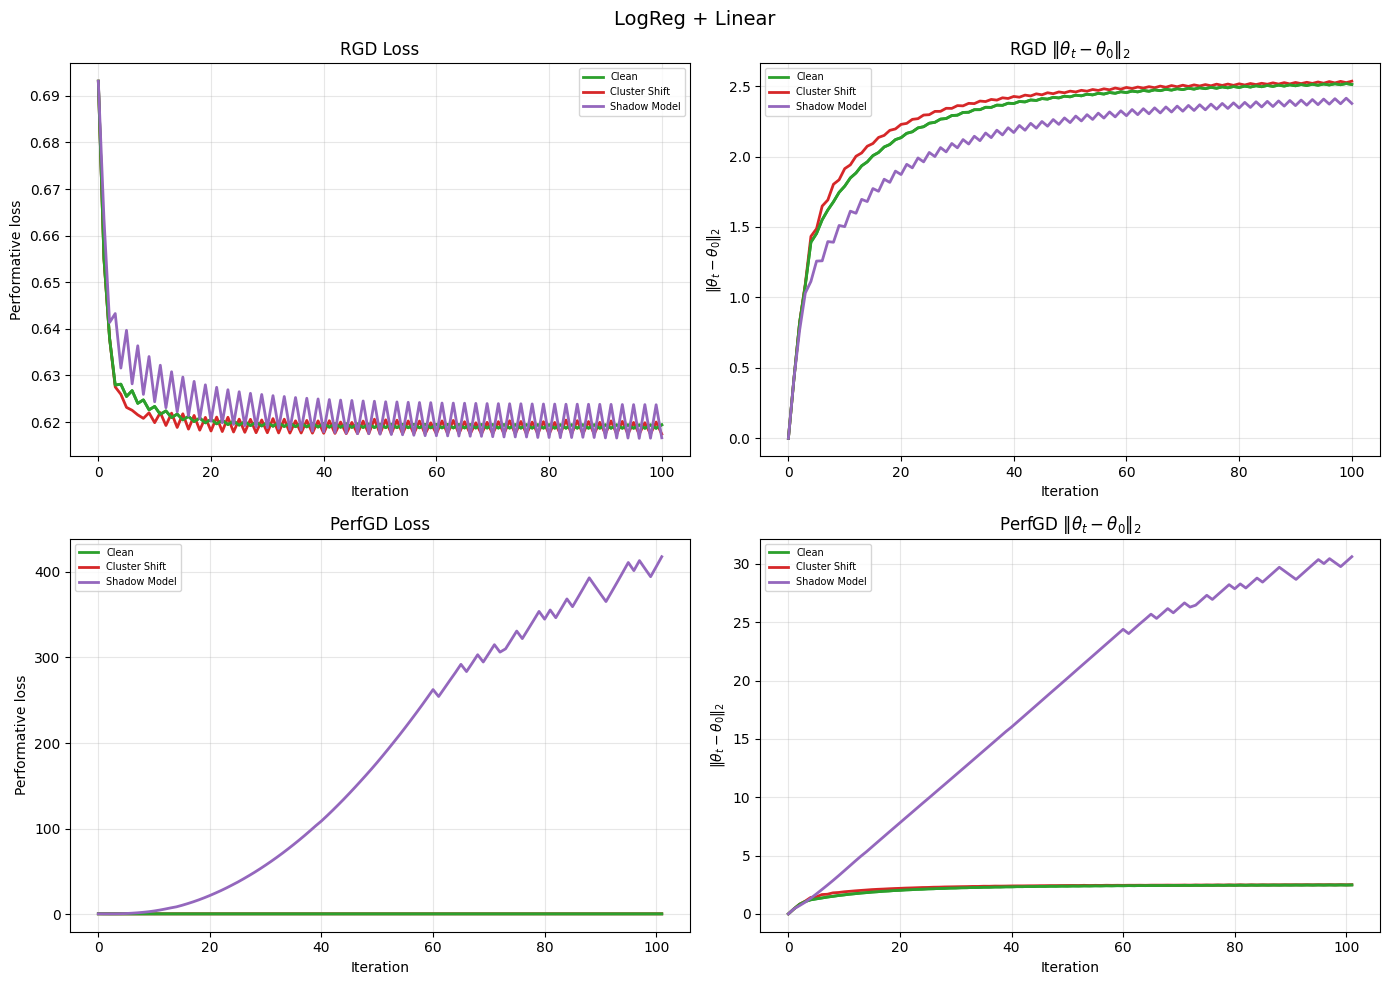

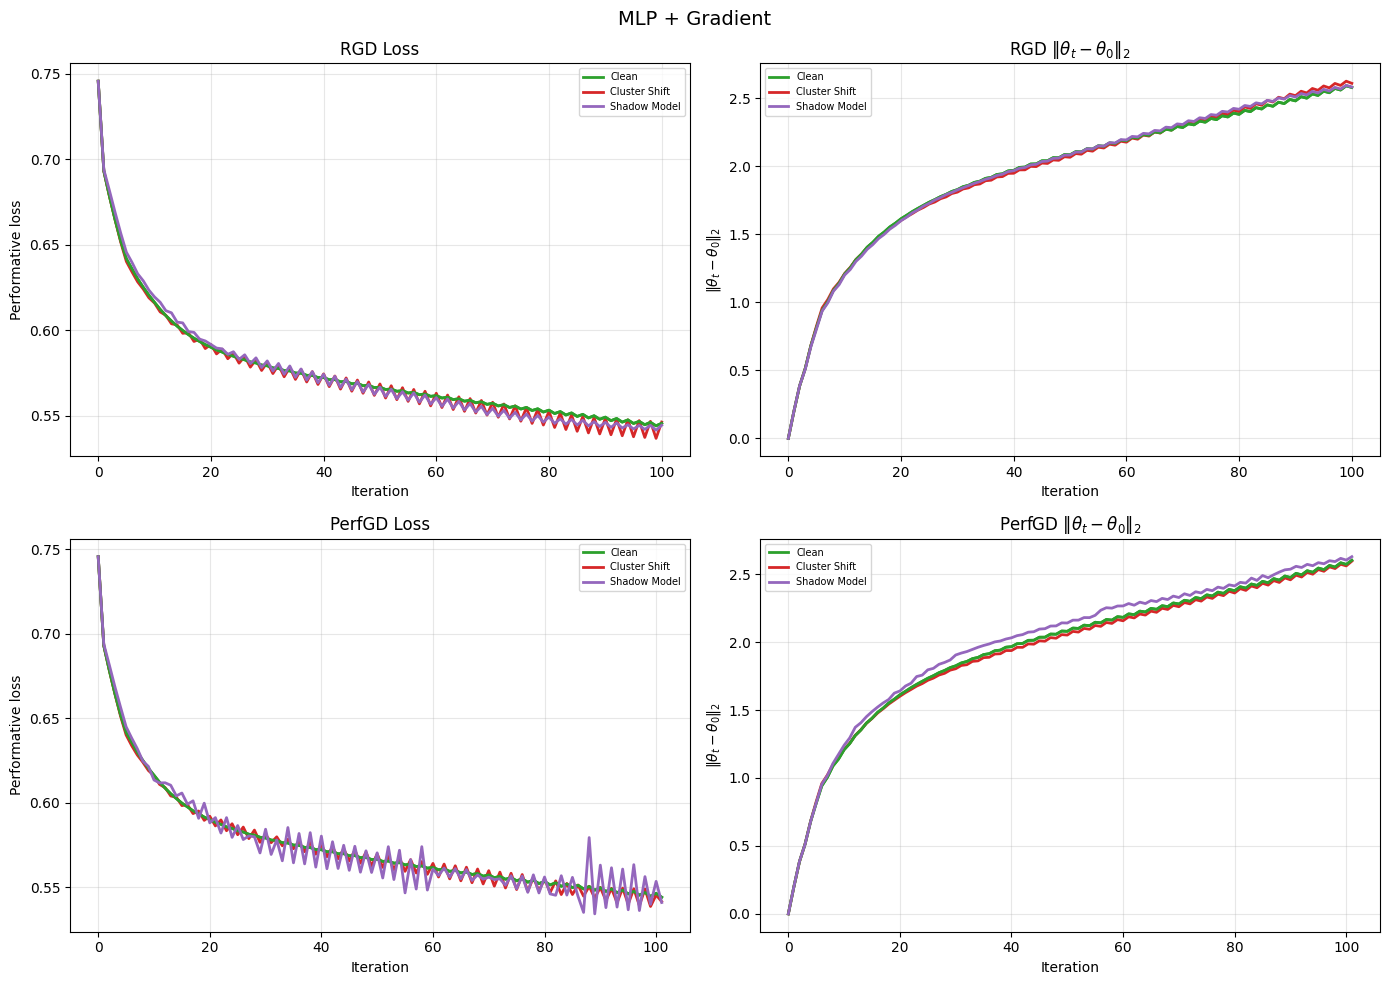

In [6]:
for model_name in models:
    model_results = {k: v for k, v in results.items() if v["model"] == model_name}
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(model_name, fontsize=14)

    attack_colors = {"Cluster Shift": "tab:red", "Shadow Model": "tab:purple"}

    for key, res in model_results.items():
        attack = res["attack"]
        c = attack_colors[attack]

        # RGD Loss
        axes[0, 0].plot(res["rgd_clean_losses"], color="tab:green", linewidth=2, label="Clean" if attack == "Cluster Shift" else None)
        axes[0, 0].plot(res["rgd_poison_losses"], color=c, linewidth=2, label=attack)

        # RGD Theta diff
        axes[0, 1].plot(res["rgd_clean_diffs"], color="tab:green", linewidth=2, label="Clean" if attack == "Cluster Shift" else None)
        axes[0, 1].plot(res["rgd_poison_diffs"], color=c, linewidth=2, label=attack)

        # PerfGD Loss
        axes[1, 0].plot(res["pgd_clean_losses"], color="tab:green", linewidth=2, label="Clean" if attack == "Cluster Shift" else None)
        axes[1, 0].plot(res["pgd_poison_losses"], color=c, linewidth=2, label=attack)

        # PerfGD Theta diff
        axes[1, 1].plot(res["pgd_clean_diffs"], color="tab:green", linewidth=2, label="Clean" if attack == "Cluster Shift" else None)
        axes[1, 1].plot(res["pgd_poison_diffs"], color=c, linewidth=2, label=attack)

    axes[0, 0].set_title("RGD Loss"); axes[0, 0].set_ylabel("Performative loss")
    axes[0, 1].set_title(r"RGD $\|\theta_t - \theta_0\|_2$"); axes[0, 1].set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
    axes[1, 0].set_title("PerfGD Loss"); axes[1, 0].set_ylabel("Performative loss")
    axes[1, 1].set_title(r"PerfGD $\|\theta_t - \theta_0\|_2$"); axes[1, 1].set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
    for ax in axes.flat:
        ax.set_xlabel("Iteration"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Cross-Model Comparison: LogReg vs MLP

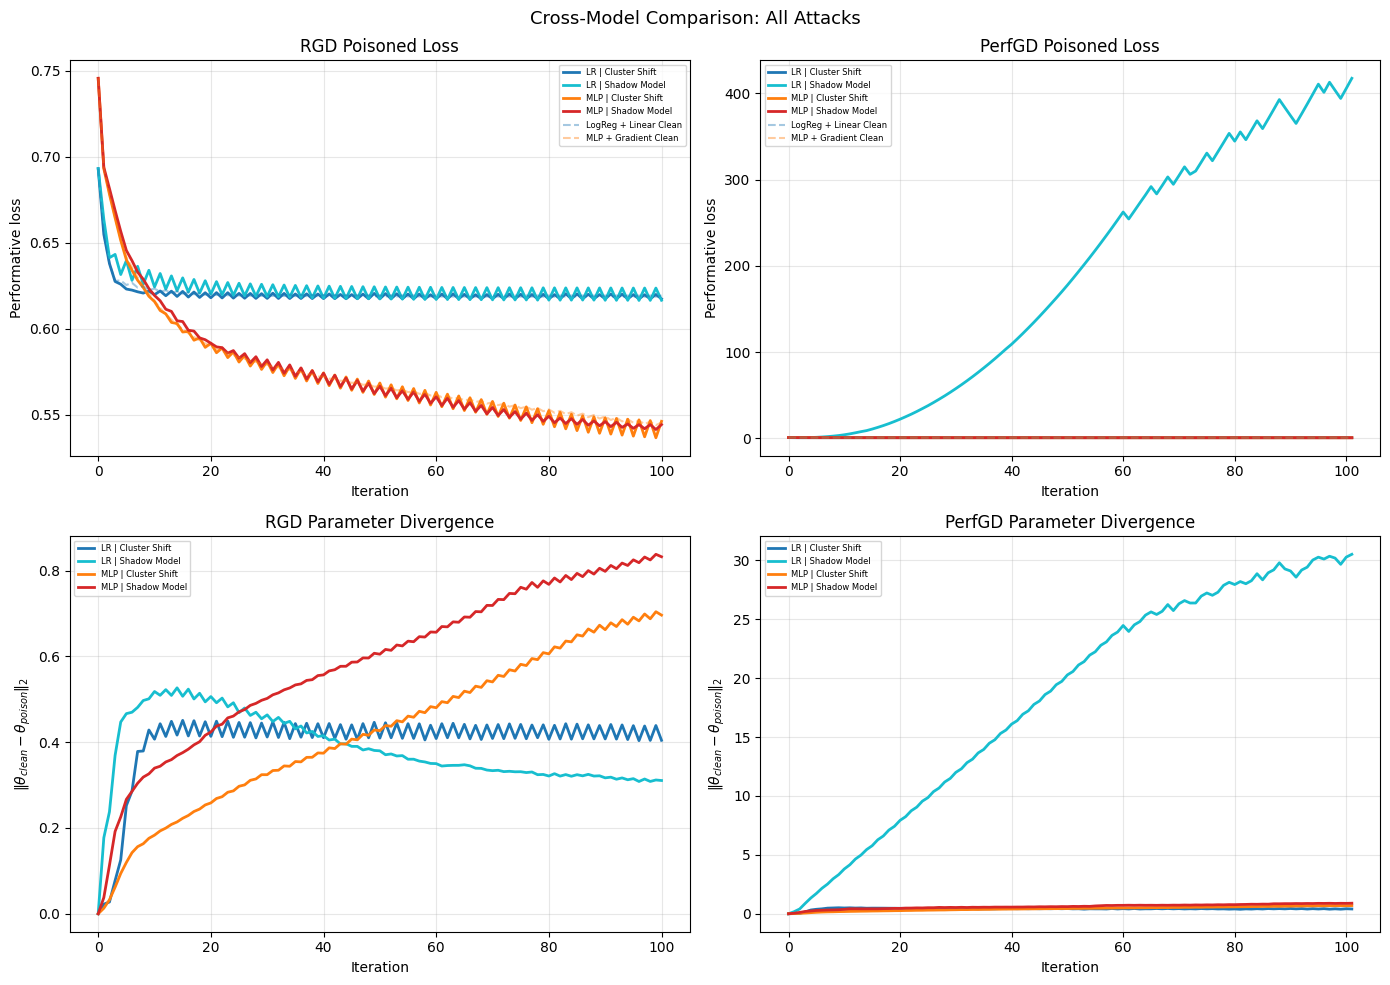

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

color_map = {
    "LogReg + Linear | Cluster Shift": "tab:blue",
    "LogReg + Linear | Shadow Model": "tab:cyan",
    "MLP + Gradient | Cluster Shift": "tab:orange",
    "MLP + Gradient | Shadow Model": "tab:red",
}

for key, res in results.items():
    c = color_map.get(key, "gray")
    short = key.replace("LogReg + Linear", "LR").replace("MLP + Gradient", "MLP")
    axes[0, 0].plot(res["rgd_poison_losses"], label=short, linewidth=2, color=c)
    axes[0, 1].plot(res["pgd_poison_losses"], label=short, linewidth=2, color=c)
    axes[1, 0].plot(res["rgd_divergence"], label=short, linewidth=2, color=c)
    axes[1, 1].plot(res["pgd_divergence"], label=short, linewidth=2, color=c)

# Add clean baselines
for model_name in models:
    first_key = [k for k in results if results[k]["model"] == model_name][0]
    res = results[first_key]
    c = "tab:blue" if "LogReg" in model_name else "tab:orange"
    axes[0, 0].plot(res["rgd_clean_losses"], linestyle="--", alpha=0.4, color=c, label=f"{model_name} Clean")
    axes[0, 1].plot(res["pgd_clean_losses"], linestyle="--", alpha=0.4, color=c, label=f"{model_name} Clean")

axes[0, 0].set_title("RGD Poisoned Loss"); axes[0, 0].set_ylabel("Performative loss")
axes[0, 1].set_title("PerfGD Poisoned Loss"); axes[0, 1].set_ylabel("Performative loss")
axes[1, 0].set_title("RGD Parameter Divergence"); axes[1, 0].set_ylabel(r"$\|\theta_{clean} - \theta_{poison}\|_2$")
axes[1, 1].set_title("PerfGD Parameter Divergence"); axes[1, 1].set_ylabel(r"$\|\theta_{clean} - \theta_{poison}\|_2$")
for ax in axes.flat:
    ax.set_xlabel("Iteration"); ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

plt.suptitle("Cross-Model Comparison: All Attacks", fontsize=13)
plt.tight_layout()
plt.show()

## Summary Table

In [8]:
print(f"{'Key':<40} {'Algo':<8} {'Clean Loss':>11} {'Poison Loss':>12} {'Delta Loss':>11} {'Divergence':>11}")
print("-" * 98)
for key, res in results.items():
    for algo, cl, pl, div in [
        ("RGD", res["rgd_clean_losses"][-1], res["rgd_poison_losses"][-1], res["rgd_divergence"][-1]),
        ("PerfGD", res["pgd_clean_losses"][-1], res["pgd_poison_losses"][-1], res["pgd_divergence"][-1]),
    ]:
        print(f"{key:<40} {algo:<8} {cl:>11.4f} {pl:>12.4f} {pl-cl:>+11.4f} {div:>11.4f}")

Key                                      Algo      Clean Loss  Poison Loss  Delta Loss  Divergence
--------------------------------------------------------------------------------------------------
LogReg + Linear | Cluster Shift          RGD           0.6194       0.6174     -0.0020      0.4045
LogReg + Linear | Cluster Shift          PerfGD        0.6238       0.6216     -0.0022      0.4053
LogReg + Linear | Shadow Model           RGD           0.6194       0.6166     -0.0028      0.3107
LogReg + Linear | Shadow Model           PerfGD        0.6238     417.5727   +416.9489     30.5259
MLP + Gradient | Cluster Shift           RGD           0.5455       0.5462     +0.0007      0.6964
MLP + Gradient | Cluster Shift           PerfGD        0.5442       0.5415     -0.0026      0.6952
MLP + Gradient | Shadow Model            RGD           0.5455       0.5443     -0.0012      0.8324
MLP + Gradient | Shadow Model            PerfGD        0.5442       0.5410     -0.0031      0.8943


## Delta Sweep: Both Models

In [9]:
delta_vals = np.linspace(0.0, 3.0, 13)
sweep_results = {}

for d_val in delta_vals:
    print(f"delta = {d_val:.2f}", end="")

    for attack_name, attack_fn in [("Cluster", cluster_shift_attack), ("Shadow", shadow_model_attack)]:
        extra = {"shift_scale": 10.0} if attack_name == "Shadow" else {}
        sweep_fn = make_strategic_poison(
            attack_fn=attack_fn, strat_features=strat_features.tolist(),
            epsilon=poison_epsilon, delta=d_val, selection="per_class", **extra)

        for model_name, m in models.items():
            key = f"{model_name} | {attack_name}"
            if key not in sweep_results:
                sweep_results[key] = {"rgd_losses": [], "pgd_losses": [], "rgd_divs": [], "pgd_divs": []}

            th_r, _, losses_r = RGD(
                D_theta=m["D_theta"], loss=m["loss"], theta_0=m["theta_0"].clone(),
                n=n, eta=m["eta"], max_iter=max_iter, proj_theta=proj_theta,
                return_losses=True, poison_function=sweep_fn)
            first_key = [k for k in results if results[k]["model"] == model_name][0]
            sweep_results[key]["rgd_losses"].append(losses_r[-1])
            sweep_results[key]["rgd_divs"].append(
                torch.norm(results[first_key]["rgd_clean_theta"] - th_r).item())

            th_p, _, losses_p = PerfGD(
                f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=m["D_theta"], loss=m["loss"],
                theta_0=m["theta_0"].clone(), n=n, eta=m["eta"], max_iter=max_iter,
                proj_theta=proj_theta, return_losses=True, poison_function=sweep_fn)
            sweep_results[key]["pgd_losses"].append(losses_p[-1])
            sweep_results[key]["pgd_divs"].append(
                torch.norm(results[first_key]["pgd_clean_theta"] - th_p).item())

    print(f" done")

print("Sweep done.")

delta = 0.00 done
delta = 0.25 done
delta = 0.50 done
delta = 0.75 done
delta = 1.00 done
delta = 1.25 done
delta = 1.50 done
delta = 1.75 done
delta = 2.00 done
delta = 2.25 done
delta = 2.50 done
delta = 2.75 done
delta = 3.00 done
Sweep done.


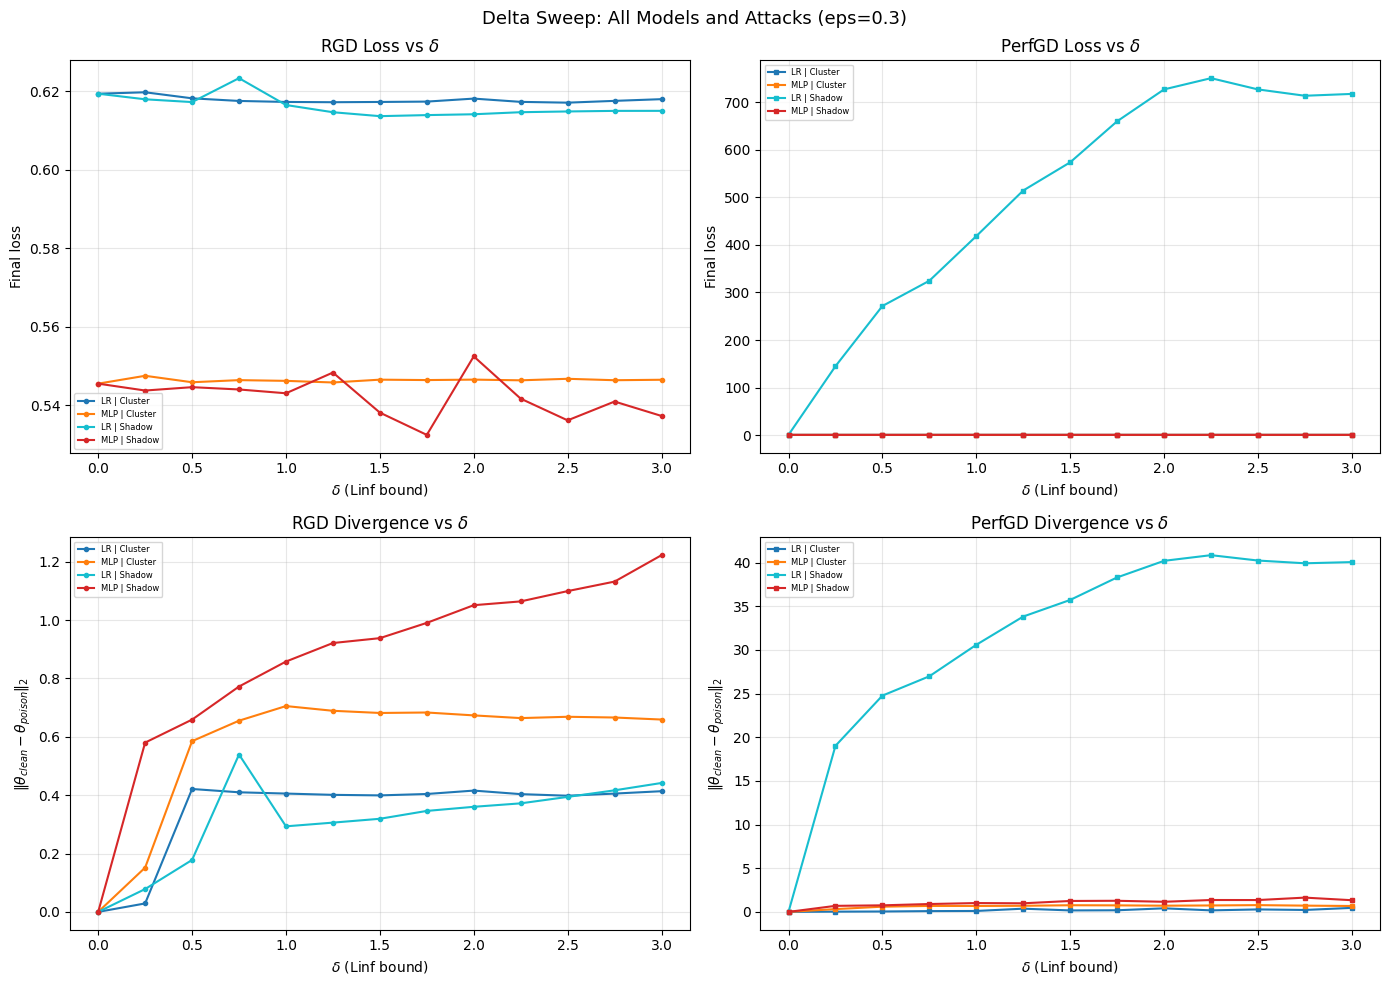

In [10]:
color_map = {
    "LogReg + Linear | Cluster": "tab:blue",
    "LogReg + Linear | Shadow": "tab:cyan",
    "MLP + Gradient | Cluster": "tab:orange",
    "MLP + Gradient | Shadow": "tab:red",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for key, sr in sweep_results.items():
    c = color_map.get(key, "gray")
    short = key.replace("LogReg + Linear", "LR").replace("MLP + Gradient", "MLP")
    axes[0, 0].plot(delta_vals, sr["rgd_losses"], marker="o", markersize=3, label=short, color=c)
    axes[0, 1].plot(delta_vals, sr["pgd_losses"], marker="s", markersize=3, label=short, color=c)
    axes[1, 0].plot(delta_vals, sr["rgd_divs"], marker="o", markersize=3, label=short, color=c)
    axes[1, 1].plot(delta_vals, sr["pgd_divs"], marker="s", markersize=3, label=short, color=c)

axes[0, 0].set_title(f"RGD Loss vs $\\delta$"); axes[0, 0].set_ylabel("Final loss")
axes[0, 1].set_title(f"PerfGD Loss vs $\\delta$"); axes[0, 1].set_ylabel("Final loss")
axes[1, 0].set_title(f"RGD Divergence vs $\\delta$"); axes[1, 0].set_ylabel(r"$\|\theta_{clean} - \theta_{poison}\|_2$")
axes[1, 1].set_title(f"PerfGD Divergence vs $\\delta$"); axes[1, 1].set_ylabel(r"$\|\theta_{clean} - \theta_{poison}\|_2$")
for ax in axes.flat:
    ax.set_xlabel(r"$\delta$ (Linf bound)"); ax.legend(fontsize=6); ax.grid(True, alpha=0.3)

plt.suptitle(f"Delta Sweep: All Models and Attacks (eps={poison_epsilon})", fontsize=13)
plt.tight_layout()
plt.show()

## Enhanced Strategic Features

Feature 0 (`RevolvingUtilizationOfUnsecuredLines`) is the only informative strategic feature — features 1 and 2 have nearly identical class distributions. We inject class-conditional Gaussian offsets into features 1 and 2 to make all three strategic dimensions separable, then run the full experiment pipeline again and compare results.

**Hypothesis:** if the collapses / weak poisoning effects observed above are due to the problem being effectively 1D, the enhanced 3D version should show meaningfully different behaviour.

In [11]:
# Configuration: class-conditional mean offsets for the non-informative strategic features.
# strat_features[1] = NumberOfOpenCreditLinesAndLoans  (uninformative)
# strat_features[2] = NumberRealEstateLoansOrLines      (uninformative)
# Keys are local indices into strat_features; values are (offset_y0, offset_y1).
enhance_means_cfg = {
    1: (-1.5, +1.5),
    2: (-1.0, +1.0),
}
enhance_noise_std = 0.3

def make_enhanced_features(X, Y, sf, feat_offsets, noise_std=0.3, seed=42):
    """Add class-conditional Gaussian noise to non-informative strategic features.

    For each entry in feat_offsets {local_idx: (mu0, mu1)}:
        y=0 agents receive additive noise ~ N(mu0, noise_std)
        y=1 agents receive additive noise ~ N(mu1, noise_std)
    This artificially separates the two clusters along those dimensions.
    """
    rng  = np.random.default_rng(seed)
    X_enh = X.clone()
    y_np  = Y.numpy().astype(int)
    for local_idx, (mu0, mu1) in feat_offsets.items():
        col   = sf[local_idx]
        noise = np.where(y_np == 0,
                         rng.normal(mu0, noise_std, size=len(y_np)),
                         rng.normal(mu1, noise_std, size=len(y_np)))
        X_enh[:, col] = X_enh[:, col] + torch.tensor(noise, dtype=torch.float32)
    return X_enh

X_enhanced = make_enhanced_features(X_full, Y_full, strat_features, enhance_means_cfg, enhance_noise_std)

# Print separation statistics
print(f"{'Feature':<42} {'--- Original ---':^30} {'--- Enhanced ---':^30}")
print(f"{'':42} {'mu_y0':>9} {'mu_y1':>9} {'|diff|':>8}    {'mu_y0':>9} {'mu_y1':>9} {'|diff|':>8}")
print("-" * 110)
for i, col in enumerate(strat_features):
    fname = data.columns[col + 1][:40]
    m0o = X_full[Y_full == 0, col].mean().item()
    m1o = X_full[Y_full == 1, col].mean().item()
    m0e = X_enhanced[Y_full == 0, col].mean().item()
    m1e = X_enhanced[Y_full == 1, col].mean().item()
    print(f"  [{i}] {fname:<40} {m0o:>+9.3f} {m1o:>+9.3f} {abs(m0o-m1o):>8.3f}    "
          f"{m0e:>+9.3f} {m1e:>+9.3f} {abs(m0e-m1e):>8.3f}")

Feature                                           --- Original ---               --- Enhanced ---       
                                               mu_y0     mu_y1   |diff|        mu_y0     mu_y1   |diff|
--------------------------------------------------------------------------------------------------------------
  [0] RevolvingUtilizationOfUnsecuredLines        -0.006    -0.009    0.003       -0.006    -0.009    0.003
  [1] NumberOfOpenCreditLinesAndLoans             +0.001    -0.100    0.101       -1.500    +1.411    2.911
  [2] NumberRealEstateLoansOrLines                -0.003    -0.011    0.008       -1.012    +0.990    2.002


### Cluster Distributions (Original vs Enhanced)

Histograms of the three strategic features colored by class label, before any strategic best-response. Feature 0 (`RevolvingUtilizationOfUnsecuredLines`) is already informative; features 1 and 2 gain class-conditional Gaussian offsets under the Enhanced setting.

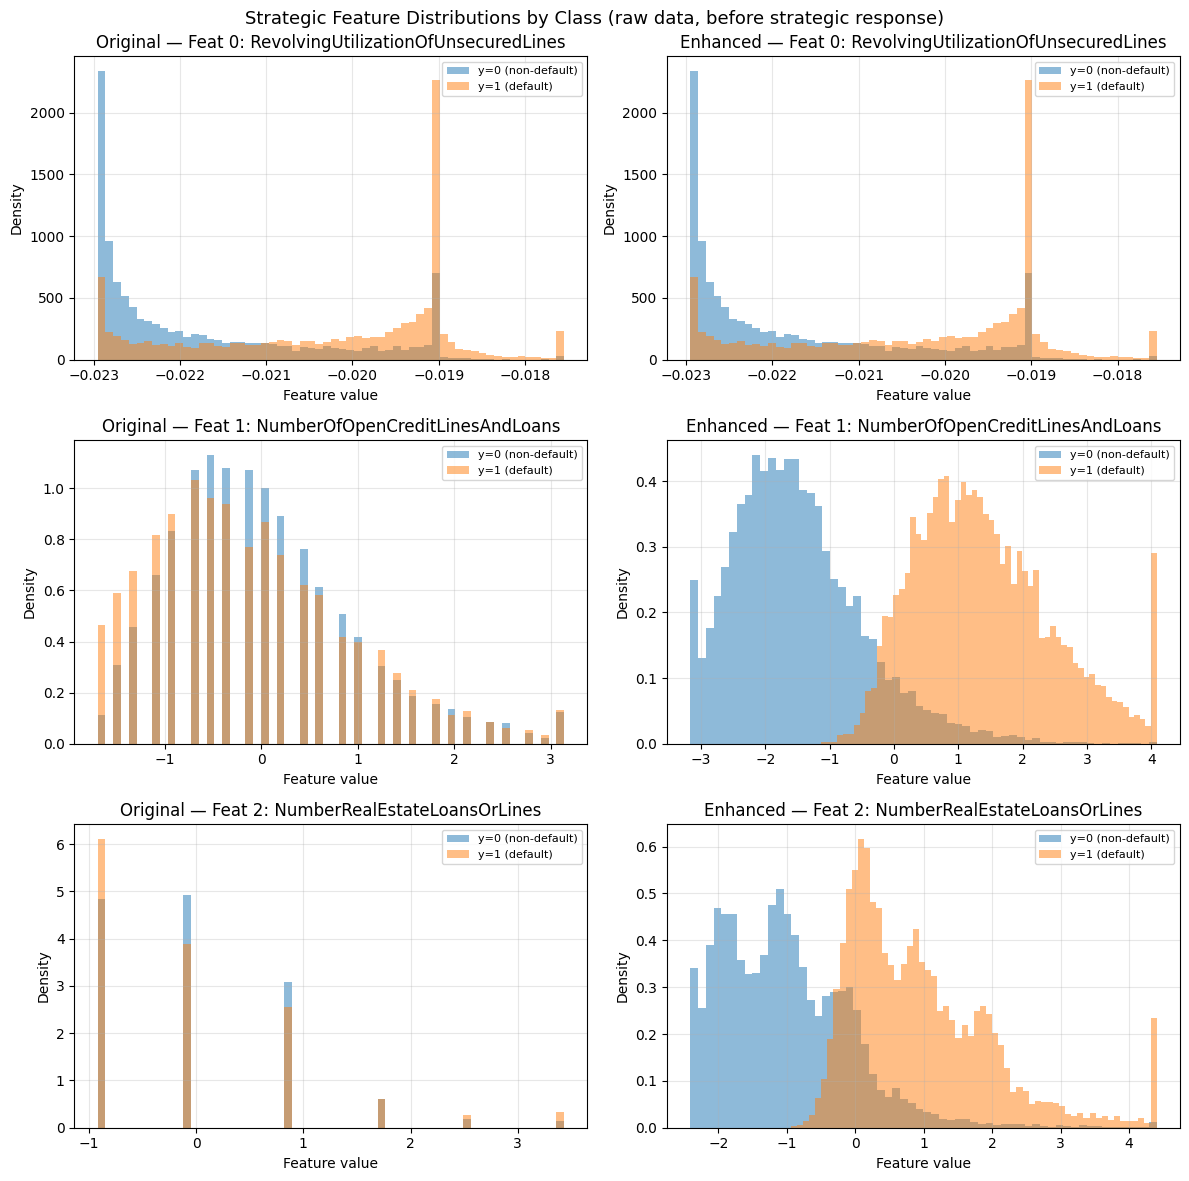

In [12]:
fig, axes = plt.subplots(len(strat_features), 2, figsize=(12, 4 * len(strat_features)))

for ri, col in enumerate(strat_features):
    fname = data.columns[col + 1]
    for ci, (X_data, title) in enumerate([(X_full, "Original"), (X_enhanced, "Enhanced")]):
        ax = axes[ri, ci]
        x0 = X_data[Y_full == 0, col].numpy()
        x1 = X_data[Y_full == 1, col].numpy()
        lo, hi = np.percentile(np.concatenate([x0, x1]), [1, 99])
        ax.hist(np.clip(x0, lo, hi), bins=60, alpha=0.5, label='y=0 (non-default)',
                color='tab:blue', density=True)
        ax.hist(np.clip(x1, lo, hi), bins=60, alpha=0.5, label='y=1 (default)',
                color='tab:orange', density=True)
        ax.set_title(f"{title} — Feat {ri}: {fname}")
        ax.set_xlabel("Feature value"); ax.set_ylabel("Density")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("Strategic Feature Distributions by Class (raw data, before strategic response)", fontsize=13)
plt.tight_layout(); plt.show()

### Model Setup for Enhanced Data

In [13]:
lam_enh = 1.0 / n_samples

(mu_f_lr_enh, sigma_lr_enh, D_theta_lr_enh,
 loss_lr_enh, theta_0_lr_enh, grad2_est_lr_enh, f_hat_lr_enh) = setup_strategic_classification(
    X_base=X_enhanced, Y_base=Y_full, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam_enh, classifier="logreg", performativity="linear", perfGD=True,
)

(mu_f_mlp_enh, sigma_mlp_enh, D_theta_mlp_enh,
 loss_mlp_enh, theta_0_mlp_enh, grad2_est_mlp_enh, f_hat_mlp_enh) = setup_strategic_classification(
    X_base=X_enhanced, Y_base=Y_full, strat_features=strat_features.tolist(),
    alpha=alpha_strat, lam=lam_enh, classifier="mlp", performativity="gradient",
    perfGD=True, hidden_dims=MLP_HIDDEN_DIMS,
)

models_enh = {
    "LogReg + Linear": {
        "D_theta": D_theta_lr_enh, "loss": loss_lr_enh, "theta_0": theta_0_lr_enh,
        "grad2_est": grad2_est_lr_enh, "f_hat": f_hat_lr_enh, "eta": eta_logreg,
        "classifier": "logreg", "hidden_dims": MLP_HIDDEN_DIMS,
    },
    "MLP + Gradient": {
        "D_theta": D_theta_mlp_enh, "loss": loss_mlp_enh, "theta_0": theta_0_mlp_enh,
        "grad2_est": grad2_est_mlp_enh, "f_hat": f_hat_mlp_enh, "eta": eta_mlp,
        "classifier": "mlp", "hidden_dims": MLP_HIDDEN_DIMS,
    },
}

print(f"LogReg + Linear (enhanced): {theta_0_lr_enh.numel()} params")
print(f"MLP + Gradient  (enhanced): {theta_0_mlp_enh.numel()} params")

LogReg + Linear (enhanced): 11 params
MLP + Gradient  (enhanced): 897 params


### Run Experiments: Enhanced Data

Same RGD / PerfGD clean + poisoned protocol, now on the enhanced feature set.

In [14]:
results_enh = {}

for model_name, m in models_enh.items():
    print(f"\n{'='*60}")
    print(f"  {model_name}  [ENHANCED]")
    print(f"{'='*60}")

    D_theta_fn = m["D_theta"]
    loss_fn    = m["loss"]
    theta_0    = m["theta_0"]
    eta        = m["eta"]

    print("  RGD Clean...", end=" ")
    th_rc, all_th_rc, losses_rc = RGD(
        D_theta=D_theta_fn, loss=loss_fn, theta_0=theta_0.clone(),
        n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_rc[-1]:.4f}")

    print("  PerfGD Clean...", end=" ")
    th_pc, all_th_pc, losses_pc = PerfGD(
        f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta_fn, loss=loss_fn,
        theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True)
    print(f"loss={losses_pc[-1]:.4f}")

    theta0 = theta_0.detach().clone()

    for attack_name, poison_fn in attacks.items():
        key = f"{model_name} | {attack_name}"
        print(f"  {attack_name}:", end="")

        print(" RGD...", end="")
        th_rp, all_th_rp, losses_rp = RGD(
            D_theta=D_theta_fn, loss=loss_fn, theta_0=theta_0.clone(),
            n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
            poison_function=poison_fn)
        print(f"{losses_rp[-1]:.4f}", end="")

        print(" PerfGD...", end="")
        th_pp, all_th_pp, losses_pp = PerfGD(
            f_hat=m["f_hat"], grad2_est=m["grad2_est"], D_theta=D_theta_fn, loss=loss_fn,
            theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
            proj_theta=proj_theta, return_losses=True,
            poison_function=poison_fn)
        print(f"{losses_pp[-1]:.4f}")

        results_enh[key] = {
            "model": model_name, "attack": attack_name,
            "rgd_clean_losses": losses_rc, "rgd_poison_losses": losses_rp,
            "pgd_clean_losses": losses_pc, "pgd_poison_losses": losses_pp,
            "rgd_clean_theta": th_rc.detach(), "rgd_poison_theta": th_rp.detach(),
            "pgd_clean_theta": th_pc.detach(), "pgd_poison_theta": th_pp.detach(),
            "all_theta_rgd_clean": all_th_rc, "all_theta_rgd_poison": all_th_rp,
            "all_theta_pgd_clean": all_th_pc, "all_theta_pgd_poison": all_th_pp,
            "theta_0": theta0,
            "rgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_rc],
            "rgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_rp],
            "pgd_clean_diffs": [(t - theta0).norm().item() for t in all_th_pc],
            "pgd_poison_diffs": [(t - theta0).norm().item() for t in all_th_pp],
            "rgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_rc, all_th_rp)],
            "pgd_divergence": [torch.norm(c - p).item() for c, p in zip(all_th_pc, all_th_pp)],
        }

print("\nDone.")


  LogReg + Linear  [ENHANCED]
  RGD Clean... loss=0.1317
  PerfGD Clean... loss=0.3418
  Cluster Shift: RGD...0.1511 PerfGD...0.3309
  Shadow Model: RGD...0.1515 PerfGD...0.2258

  MLP + Gradient  [ENHANCED]
  RGD Clean... loss=0.0748
  PerfGD Clean... loss=0.0791
  Cluster Shift: RGD...0.1114 PerfGD...0.1063
  Shadow Model: RGD...0.0879 PerfGD...0.1485

Done.


### Cluster Visualization: Before & After Poisoning

Strategic feature distributions evaluated at the converged clean θ, comparing the honest best-response (Clean) vs each attack. Rows = strategic features; columns = Original/Enhanced × Clean/ClusterShift/ShadowModel.

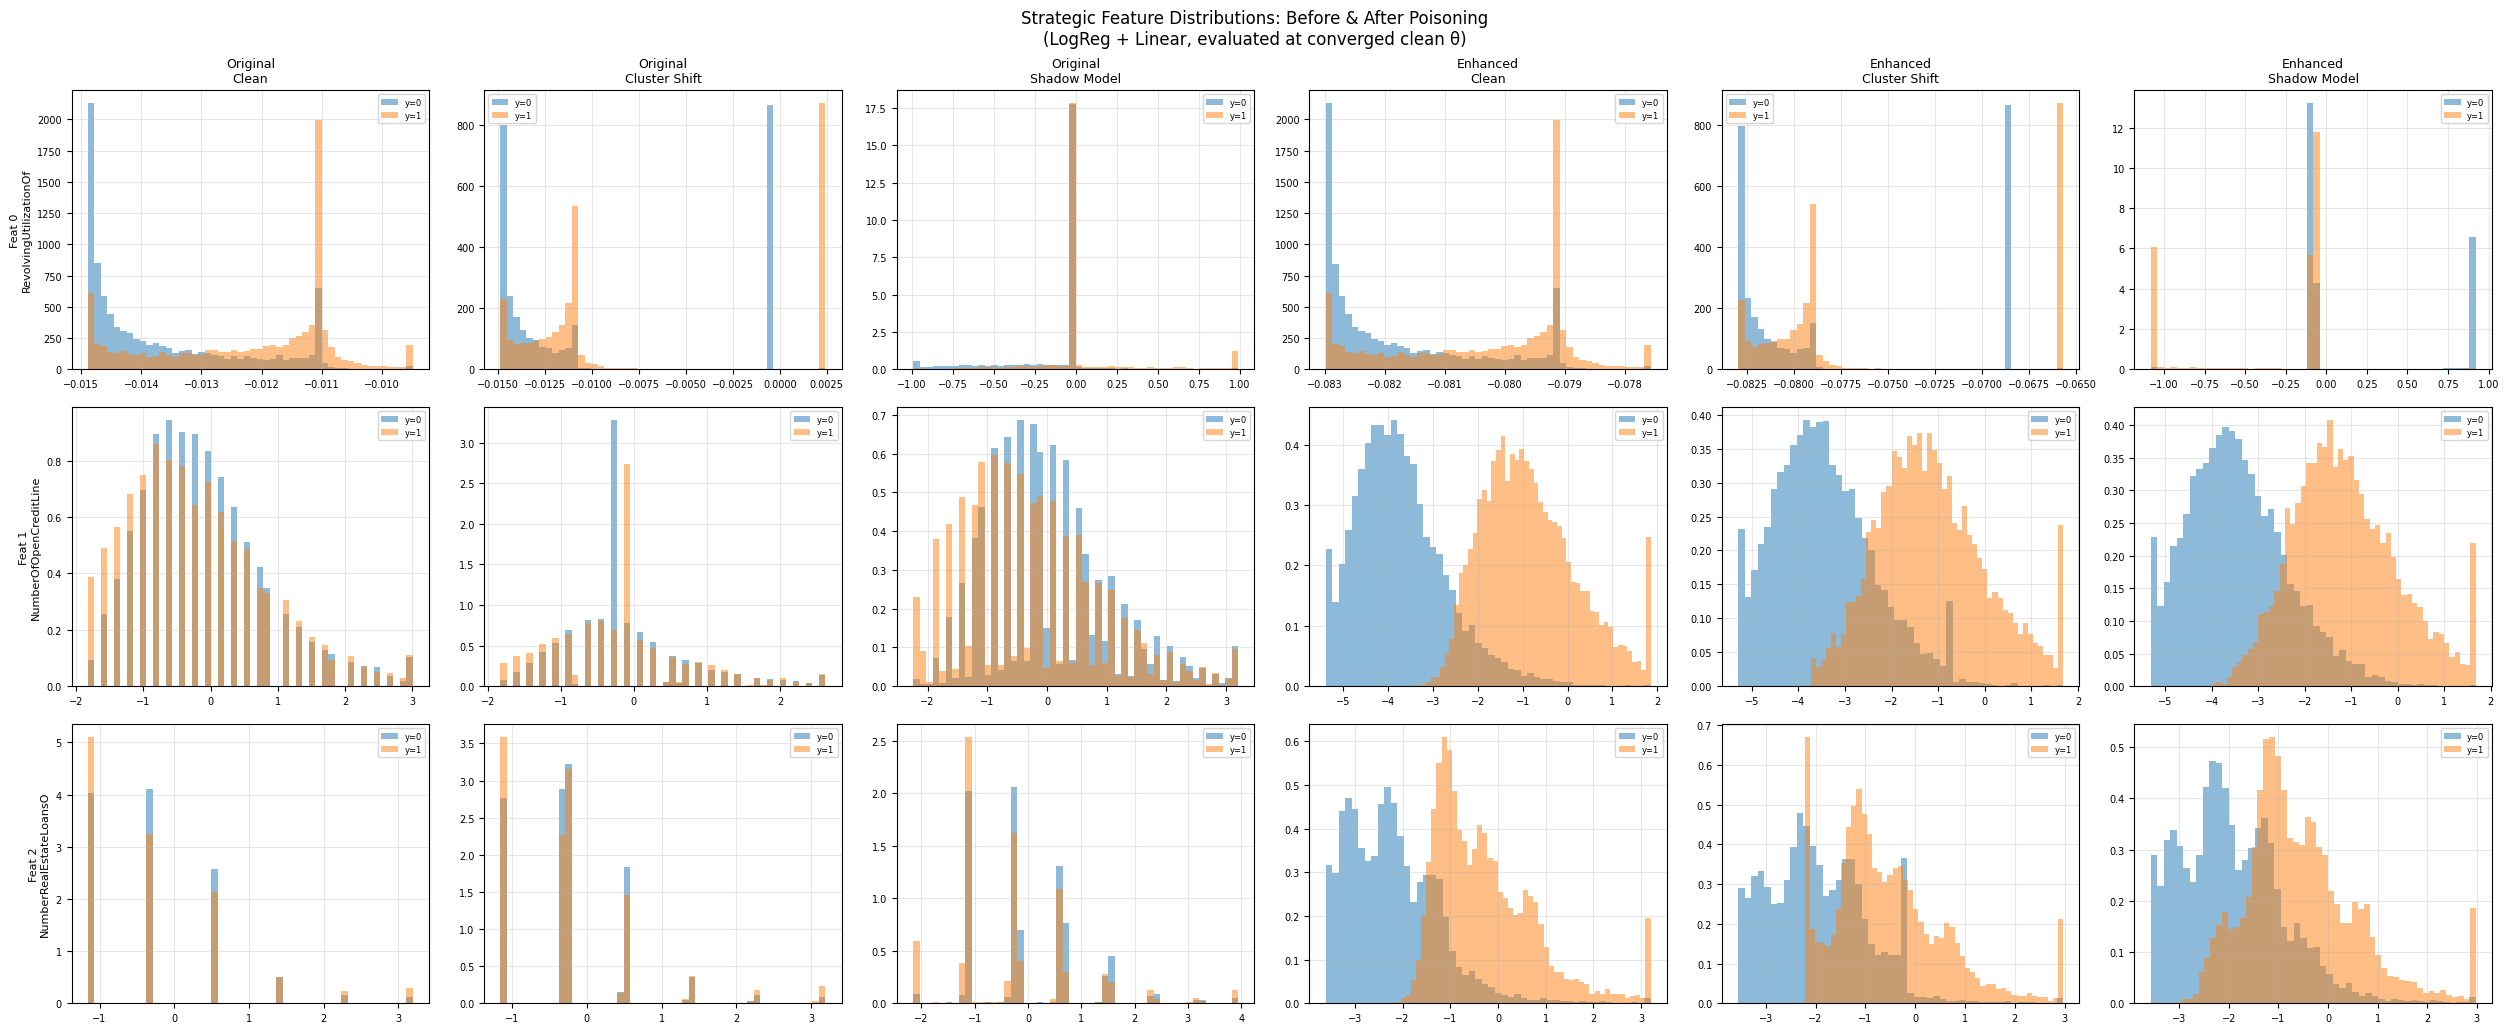

In [15]:
# Use LogReg + Linear for interpretable cluster visualization.
# Evaluate at the converged clean RGD theta for each dataset.
theta_orig_lr = results["LogReg + Linear | Cluster Shift"]["rgd_clean_theta"]
theta_enh_lr  = results_enh["LogReg + Linear | Cluster Shift"]["rgd_clean_theta"]

with torch.no_grad():
    # n > n_total triggers full-batch path in D_theta (no random sampling)
    z_orig_clean   = D_theta_lr(theta_orig_lr, n_samples + 1)
    z_enh_clean    = D_theta_lr_enh(theta_enh_lr, n_samples + 1)

    z_orig_cluster = cluster_fn(z_orig_clean,  theta_orig_lr)
    z_orig_shadow  = shadow_fn(z_orig_clean,   theta_orig_lr)
    z_enh_cluster  = cluster_fn(z_enh_clean,   theta_enh_lr)
    z_enh_shadow   = shadow_fn(z_enh_clean,    theta_enh_lr)

def extract_strat_feats(z):
    idx_t = torch.tensor(strat_features, dtype=torch.long)
    return z[idx_t, :].T.numpy(), z[-1, :].numpy()

states_bap = {
    "Original\nClean":          extract_strat_feats(z_orig_clean),
    "Original\nCluster Shift":  extract_strat_feats(z_orig_cluster),
    "Original\nShadow Model":   extract_strat_feats(z_orig_shadow),
    "Enhanced\nClean":          extract_strat_feats(z_enh_clean),
    "Enhanced\nCluster Shift":  extract_strat_feats(z_enh_cluster),
    "Enhanced\nShadow Model":   extract_strat_feats(z_enh_shadow),
}

n_sf = len(strat_features)
n_st = len(states_bap)

fig, axes = plt.subplots(n_sf, n_st, figsize=(4.2 * n_st, 3.5 * n_sf))
for ri, sf_col in enumerate(strat_features):
    fname = data.columns[sf_col + 1]
    for ci, (state_lbl, (x_s, y_s)) in enumerate(states_bap.items()):
        ax = axes[ri, ci]
        x0 = x_s[y_s == 0, ri]; x1 = x_s[y_s == 1, ri]
        lo, hi = np.percentile(np.concatenate([x0, x1]), [1, 99])
        ax.hist(np.clip(x0, lo, hi), bins=50, alpha=0.5, label='y=0',
                color='tab:blue', density=True)
        ax.hist(np.clip(x1, lo, hi), bins=50, alpha=0.5, label='y=1',
                color='tab:orange', density=True)
        if ri == 0: ax.set_title(state_lbl, fontsize=9)
        if ci == 0: ax.set_ylabel(f"Feat {ri}\n{fname[:22]}", fontsize=8)
        ax.legend(fontsize=6); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=7)

plt.suptitle("Strategic Feature Distributions: Before & After Poisoning\n"
             "(LogReg + Linear, evaluated at converged clean θ)", fontsize=12)
plt.tight_layout(); plt.show()

### Loss & Convergence: Original vs Enhanced

Side-by-side comparison of loss curves and parameter displacement across algorithms and attacks. If the enhanced features reduce the "collapse" seen in the original experiments, this confirms the 1D nature of the problem.

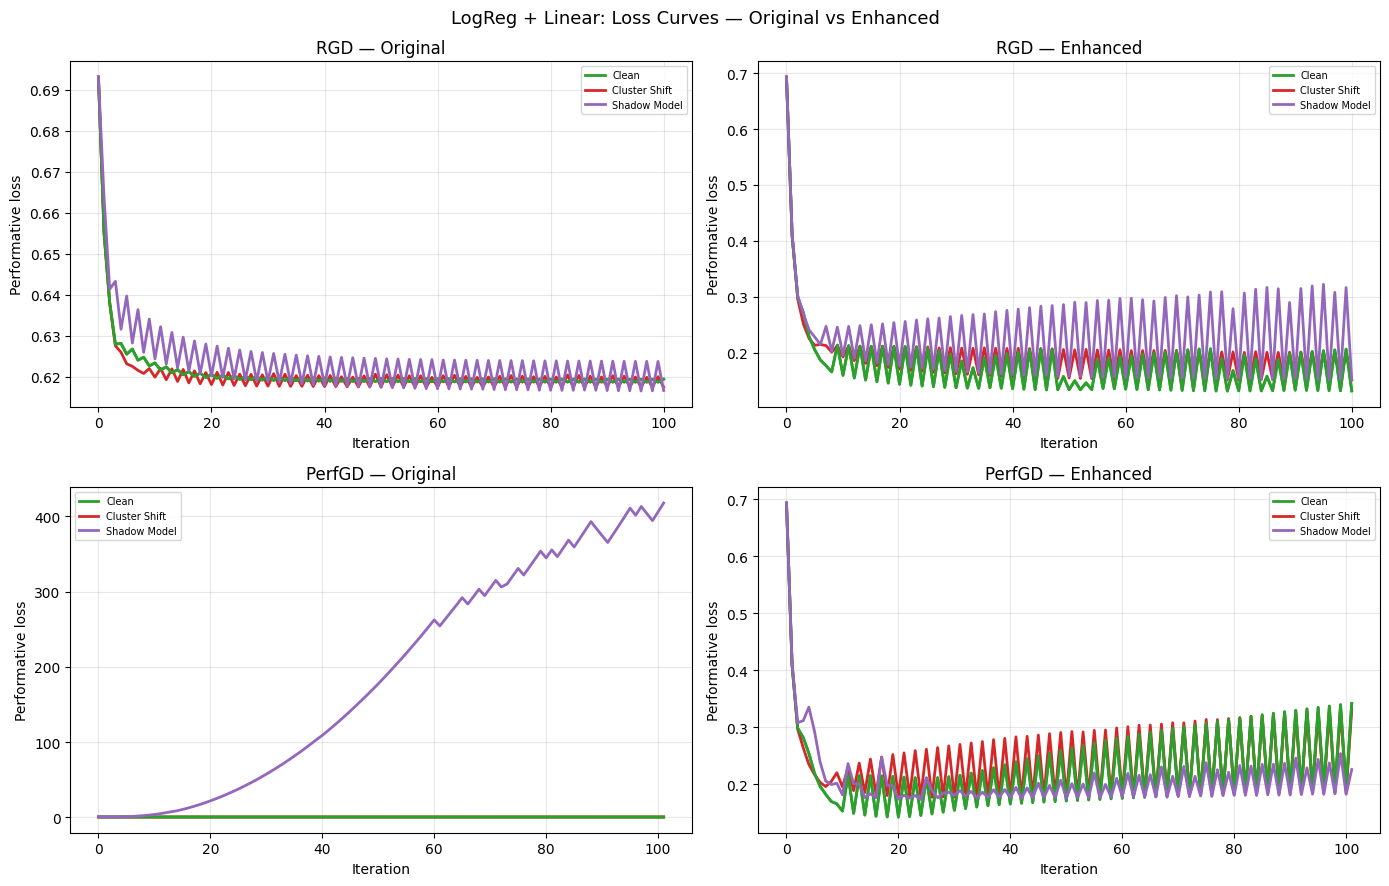

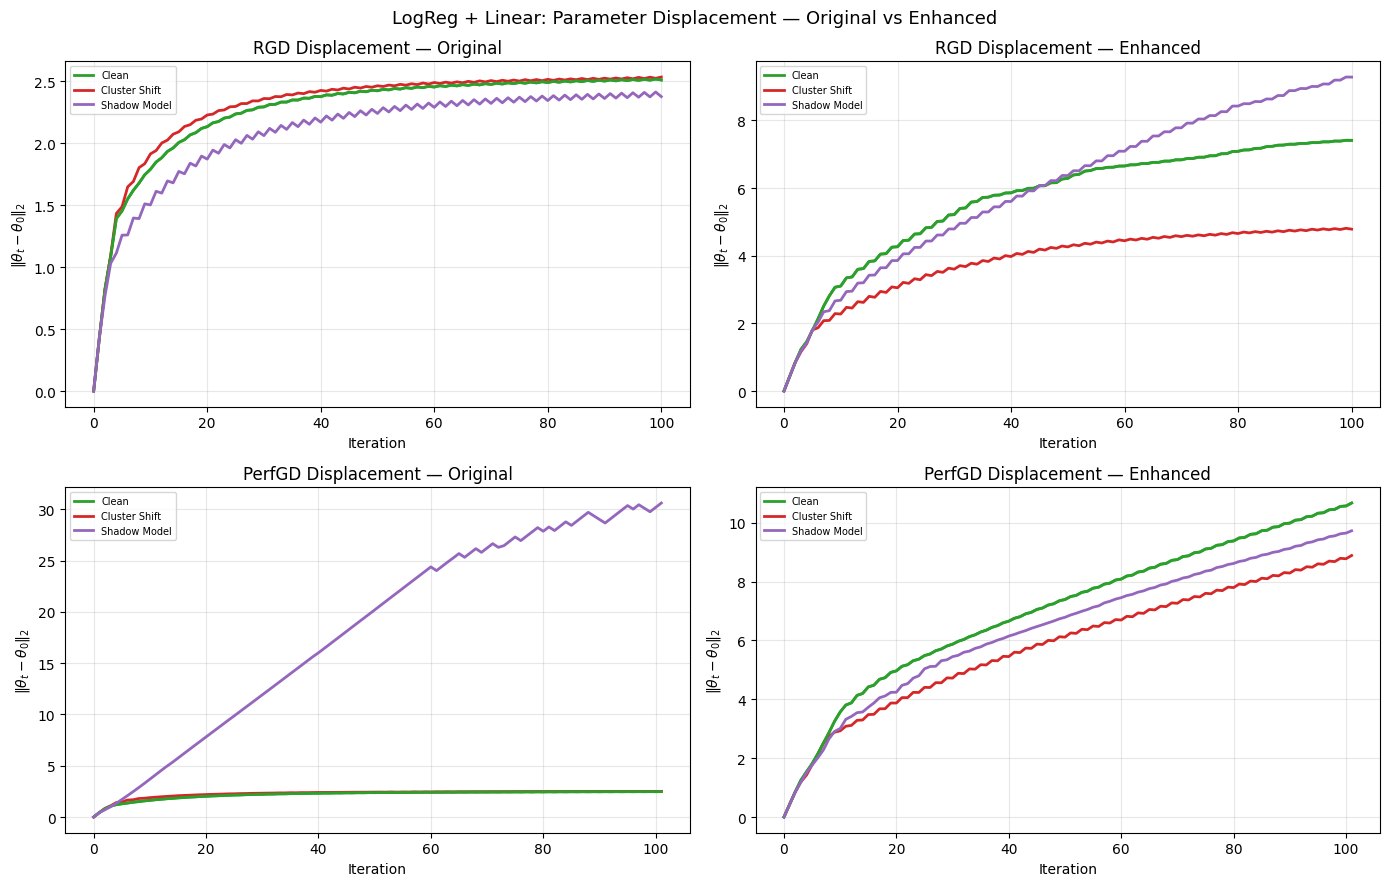

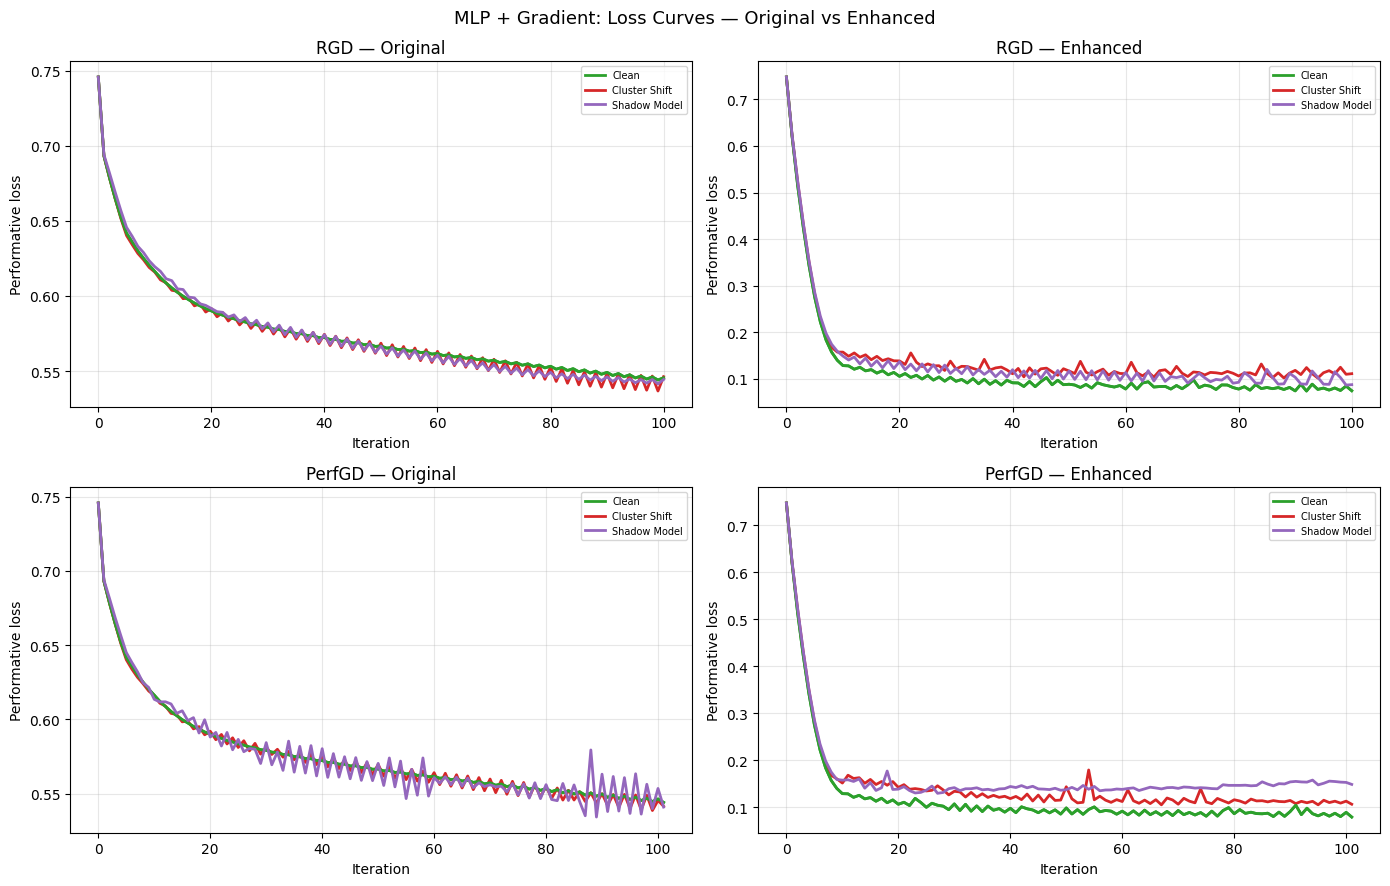

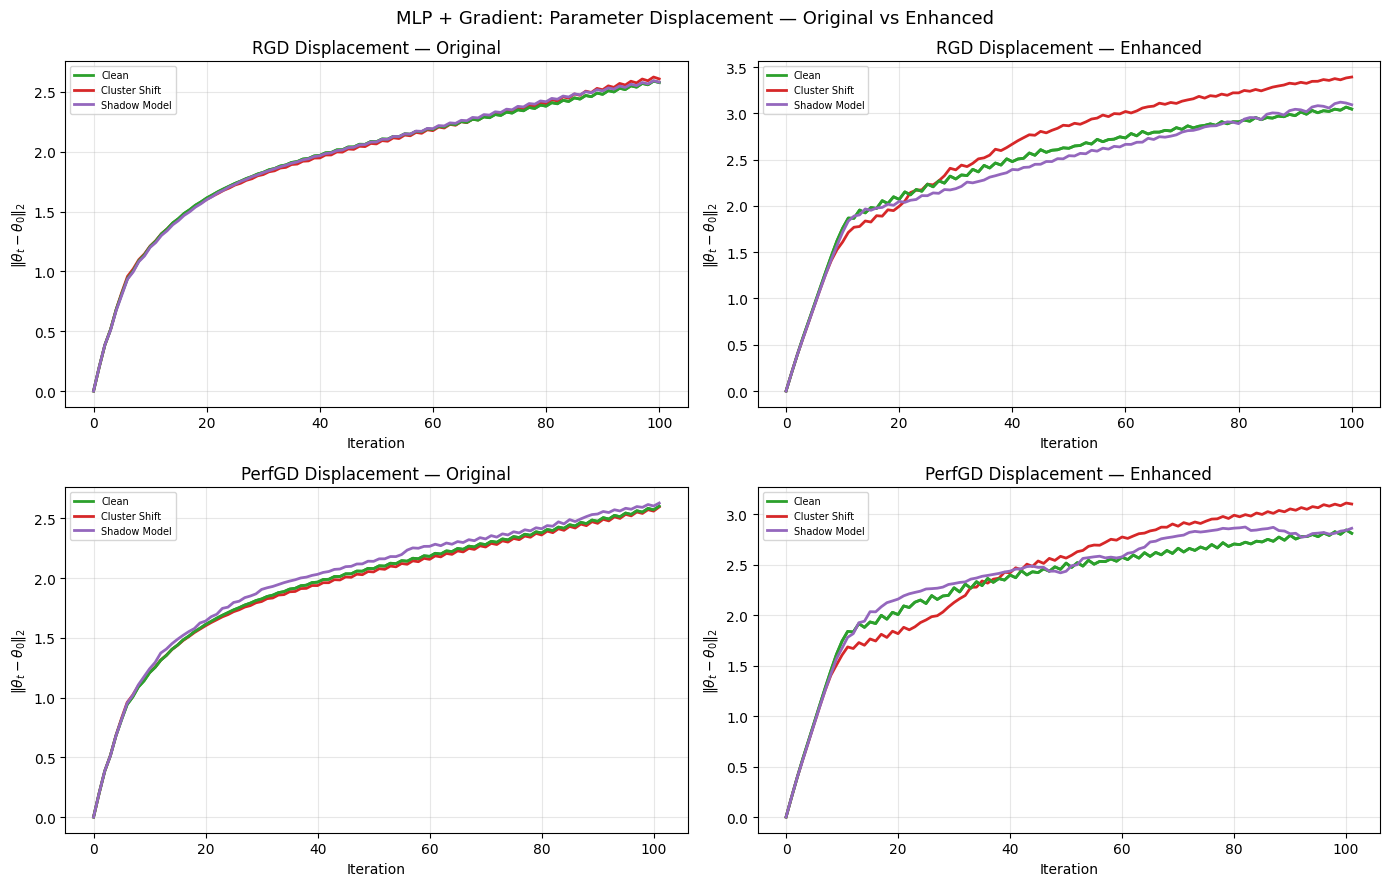

In [16]:
attack_colors_cmp = {"Cluster Shift": "tab:red", "Shadow Model": "tab:purple"}

for model_name in models:
    orig = {k: v for k, v in results.items() if v["model"] == model_name}
    enh  = {k: v for k, v in results_enh.items() if v["model"] == model_name}

    # --- Loss curves ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"{model_name}: Loss Curves — Original vs Enhanced", fontsize=13)

    for col, (res_dict, lbl) in enumerate([(orig, "Original"), (enh, "Enhanced")]):
        first_attack = list(attacks.keys())[0]
        for key, res in res_dict.items():
            attack = res["attack"]
            c = attack_colors_cmp[attack]
            first = (attack == first_attack)
            axes[0, col].plot(res["rgd_clean_losses"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[0, col].plot(res["rgd_poison_losses"], color=c, linewidth=2, label=attack)
            axes[1, col].plot(res["pgd_clean_losses"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[1, col].plot(res["pgd_poison_losses"], color=c, linewidth=2, label=attack)
        axes[0, col].set_title(f"RGD — {lbl}")
        axes[1, col].set_title(f"PerfGD — {lbl}")

    for ax in axes.flat:
        ax.set_xlabel("Iteration"); ax.set_ylabel("Performative loss")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # --- Parameter displacement ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"{model_name}: Parameter Displacement — Original vs Enhanced", fontsize=13)

    for col, (res_dict, lbl) in enumerate([(orig, "Original"), (enh, "Enhanced")]):
        first_attack = list(attacks.keys())[0]
        for key, res in res_dict.items():
            attack = res["attack"]
            c = attack_colors_cmp[attack]
            first = (attack == first_attack)
            axes[0, col].plot(res["rgd_clean_diffs"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[0, col].plot(res["rgd_poison_diffs"], color=c, linewidth=2, label=attack)
            axes[1, col].plot(res["pgd_clean_diffs"], color="tab:green", linewidth=2,
                              label="Clean" if first else None)
            axes[1, col].plot(res["pgd_poison_diffs"], color=c, linewidth=2, label=attack)
        axes[0, col].set_title(f"RGD Displacement — {lbl}")
        axes[1, col].set_title(f"PerfGD Displacement — {lbl}")

    for ax in axes.flat:
        ax.set_xlabel("Iteration"); ax.set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()